In [196]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame oluşturma
df = pd.read_csv('csv_data/test.csv')


In [197]:
df

,GÜN,RÜZGAR HIZI (KM/SAAT),Sıcaklık (°C),Nem Seviyesi (%),Yağmur Olasılığı (%)
0,1,34,21,78,122
1,2,15,22,21,27
2,3,11,21,89,43
3,4,6,6,90,53
4,5,18,-10,43,140
...,...,...,...,...,...
195,196,108,28,72,24
196,197,21,21,66,21
197,198,51,28,60,20
198,199,12,15,15,148


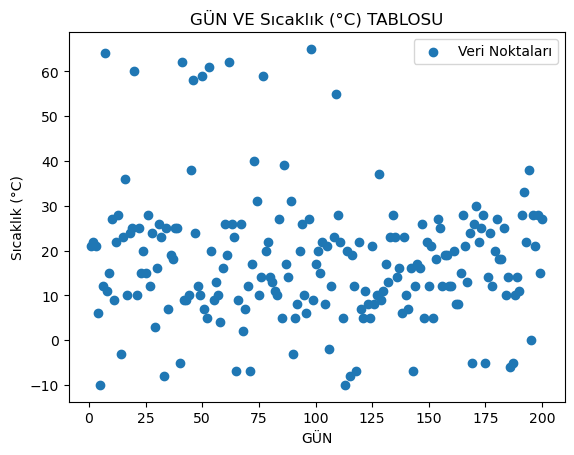

In [198]:
plt.scatter(df['GÜN'], df['Sıcaklık (°C)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('Sıcaklık (°C)')
plt.title('GÜN VE Sıcaklık (°C) TABLOSU')
plt.legend()
plt.show()

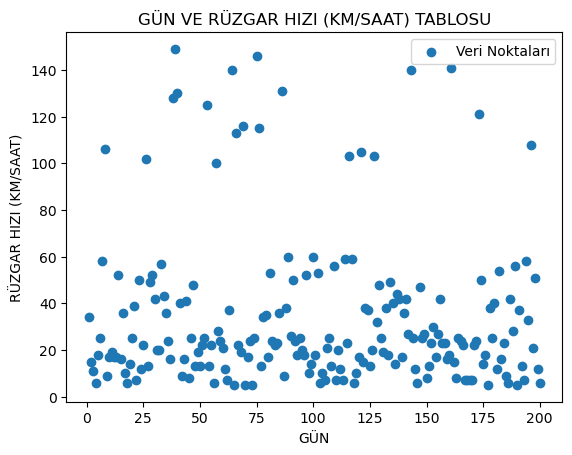

In [199]:
plt.scatter(df['GÜN'], df['RÜZGAR HIZI (KM/SAAT)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('RÜZGAR HIZI (KM/SAAT)')
plt.title('GÜN VE RÜZGAR HIZI (KM/SAAT) TABLOSU')
plt.legend()
plt.show()

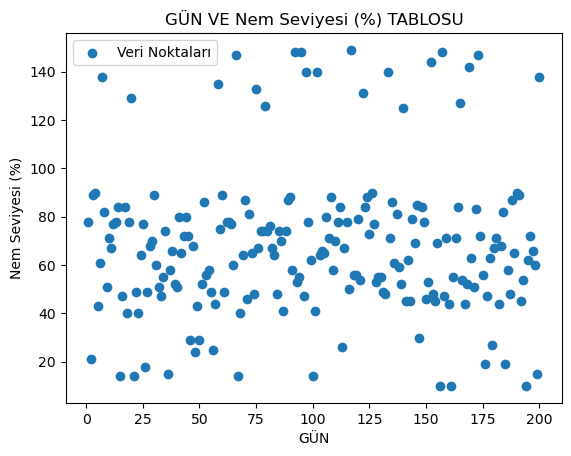

In [200]:
plt.scatter(df['GÜN'], df['Nem Seviyesi (%)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('Nem Seviyesi (%)')
plt.title('GÜN VE Nem Seviyesi (%) TABLOSU')
plt.legend()
plt.show()

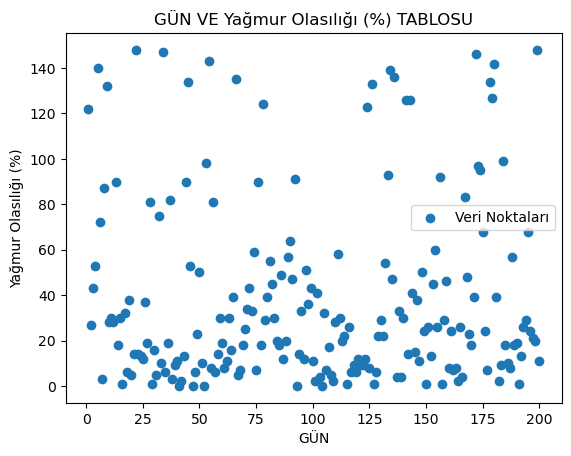

In [201]:
plt.scatter(df['GÜN'], df['Yağmur Olasılığı (%)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('Yağmur Olasılığı (%)')
plt.title('GÜN VE Yağmur Olasılığı (%) TABLOSU')
plt.legend()
plt.show()

In [202]:

# IQR fonksiyonu
def detect_outliers_iqr(df):
    outliers = {}
    cleaned_df = df.copy()  # Orijinal veri setini korumak için
    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
    
    for column in numeric_columns:
        # 1. ve 3. çeyrekleri hesaplama (Q1, Q3)
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        
        # IQR'yi hesapla
        IQR = Q3 - Q1
        
        # Alt ve üst sınırları hesapla
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Aykırı değerlerin tespit edilmesi
        outliers[column] = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        
        # Aykırı değerleri kaldırma
        cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]
    
    return cleaned_df, outliers

# Aykırı (outliers) değerleri temizle
cleaned_df, outliers = detect_outliers_iqr(df)

# Aykırı değerlerin bulunduğu sütunları yazdırma

# Temizlenmiş veriyi yeni bir CSV dosyasına kaydetme
cleaned_df.to_csv('test_IQR.csv', index=False)

print("\nAykırı veriler temizlendi ve 'csv_data/test_IQR.csv' dosyasına kaydedildi.")



Aykırı veriler temizlendi ve 'test_IQR.csv' dosyasına kaydedildi.


In [203]:
for column, outlier_data in outliers.items():
    if not outlier_data.empty:
        print(f"\nOutliers in '{column}':")
        print(outlier_data)


Outliers in 'RÜZGAR HIZI (KM/SAAT)':
     GÜN  RÜZGAR HIZI (KM/SAAT)  Sıcaklık (°C)  Nem Seviyesi (%)  \
7      8                    106             11                82   
25    26                    102             28                18   
37    38                    128             25                66   
38    39                    149             25                52   
39    40                    130             -5                51   
52    53                    125             61                56   
56    57                    100             10                44   
63    64                    140             23                77   
65    66                    113              9               147   
68    69                    116              7                64   
74    75                    146             10               133   
75    76                    115             14                67   
85    86                    131             39                70   
115  116  

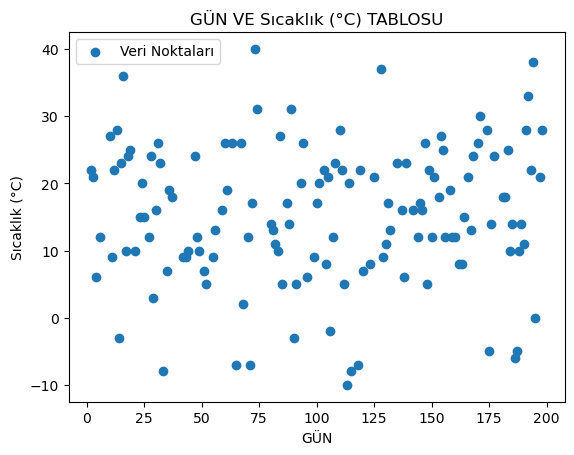

In [204]:
plt.scatter(cleaned_df['GÜN'], cleaned_df['Sıcaklık (°C)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('Sıcaklık (°C)')
plt.title('GÜN VE Sıcaklık (°C) TABLOSU')
plt.legend()
plt.show()

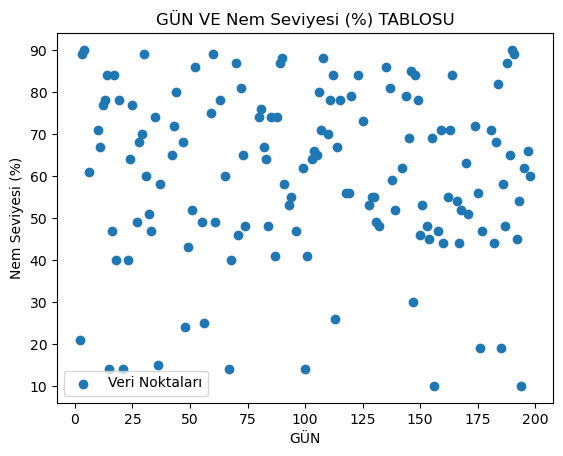

In [205]:
plt.scatter(cleaned_df['GÜN'], cleaned_df['Nem Seviyesi (%)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('Nem Seviyesi (%)')
plt.title('GÜN VE Nem Seviyesi (%) TABLOSU')
plt.legend()
plt.show()

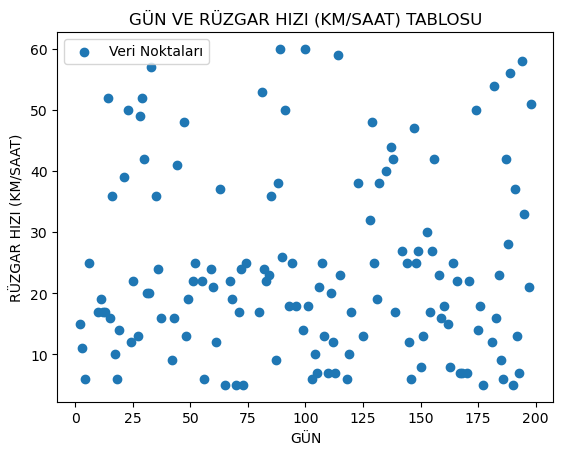

In [206]:
plt.scatter(cleaned_df['GÜN'], cleaned_df['RÜZGAR HIZI (KM/SAAT)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('RÜZGAR HIZI (KM/SAAT)')
plt.title('GÜN VE RÜZGAR HIZI (KM/SAAT) TABLOSU')
plt.legend()
plt.show()

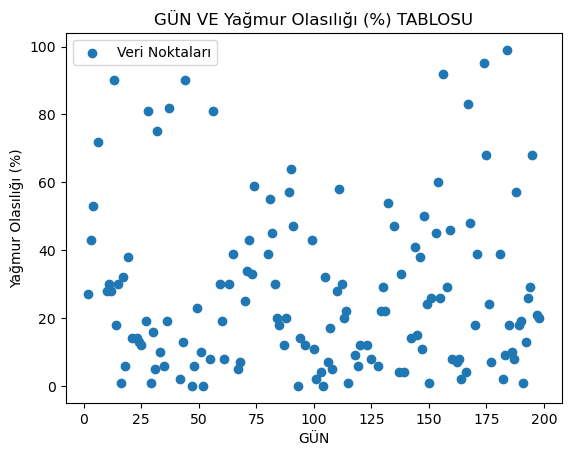

In [207]:
plt.scatter(cleaned_df['GÜN'], cleaned_df['Yağmur Olasılığı (%)'], label='Veri Noktaları')
plt.xlabel('GÜN')
plt.ylabel('Yağmur Olasılığı (%)')
plt.title('GÜN VE Yağmur Olasılığı (%) TABLOSU')
plt.legend()
plt.show()